# Task 1

In [4]:
# Using Pennylane
import pennylane as qml
from pennylane import numpy as np

# a) Initialize 5 qubits
dev = qml.device("default.qubit", wires=5)

@qml.qnode(dev)
def circuit():
    # b) Apply Hadamard on every qubit
    for i in range(5):
        qml.Hadamard(wires=i)

    # c) Apply CNOT sequentially: (0,1), (1,2), (2,3), (3,4)
    for i in range(4):
        qml.CNOT(wires=[i, i + 1])

    # d) SWAP (0, 4)
    qml.SWAP(wires=[0, 4])

    # e) Rotate X with pi/2 on qubit 2
    qml.RX(np.pi / 2, wires=2)

    return qml.state()

# f) Print the circuit
print("Task 1: PennyLane Circuit")
print(qml.draw(circuit)())

Task 1: PennyLane Circuit
0: ──H─╭●──────────╭SWAP───────────┤  State
1: ──H─╰X─╭●───────│───────────────┤  State
2: ──H────╰X─╭●────│──────RX(1.57)─┤  State
3: ──H───────╰X─╭●─│───────────────┤  State
4: ──H──────────╰X─╰SWAP───────────┤  State


In [8]:
import pennylane as qml
from pennylane import numpy as np

# Initialize 5 qubits
# Wires 0,1: State 1 |q0 q1>
# Wires 2,3: State 2 |q2 q3>
# Wire 4: Ancilla qubit
dev = qml.device("default.qubit", wires=5)

@qml.qnode(dev)
def swap_test():
    # --- State Preparation ---
    # Apply Hadamard to the first qubit
    qml.Hadamard(wires=0)

    # Rotate the second qubit by pi/3 around X
    qml.RX(np.pi / 3, wires=1)

    # Apply Hadamard to the third and fourth qubit
    qml.Hadamard(wires=2)
    qml.Hadamard(wires=3)

    qml.Barrier(wires=range(5))

    # --- SWAP Test Subroutine ---
    # Step 1: Put the ancilla in superposition
    qml.Hadamard(wires=4)

    # Step 2: Controlled-SWAP (Fredkin) gates
    qml.CSWAP(wires=[4, 0, 2])  # control=4, swap q0 <-> q2
    qml.CSWAP(wires=[4, 1, 3])  # control=4, swap q1 <-> q3

    # Step 3: Interfere the ancilla
    qml.Hadamard(wires=4)

    # Step 4: Measure the ancilla
    # Prob of |0> on ancilla indicates similarity; |1> indicates orthogonality
    return qml.probs(wires=4)

# Run and display
print("Task 2: PennyLane SWAP Test Circuit")
print(qml.draw(swap_test)())

probs = swap_test()
print(f"\nAncilla probabilities: |0> = {probs[0]:.4f}, |1> = {probs[1]:.4f}")

Task 2: PennyLane SWAP Test Circuit
0: ──H────────╭||────╭SWAP──────────┤       
1: ──RX(1.05)─├||────│─────╭SWAP────┤       
2: ──H────────├||────├SWAP─│────────┤       
3: ──H────────├||────│─────├SWAP────┤       
4: ───────────╰||──H─╰●────╰●─────H─┤  Probs

Ancilla probabilities: |0> = 0.7500, |1> = 0.2500


# Task II

Using device: cpu
Total jets       : 100000
Max constituents : 139
Features/particle: 4
Class distribution: Quarks(0)=50000, Gluons(1)=50000

Sample jet: 18 real particles out of 139 padded slots
First 5 particles:
[[ 2.68769142e-01  3.56903171e-01  4.74138734e+00  2.20000000e+01]
 [ 1.60076377e-01 -2.55609533e-01  4.55022910e+00  2.20000000e+01]
 [ 1.14868731e+00 -6.24380156e-02  4.50385377e+00 -2.11000000e+02]
 [ 4.13159146e+00  1.73686350e-01  4.76622410e+00 -3.21000000e+02]
 [ 1.69599701e+00 -2.12177764e-01  4.79687162e+00 -2.11000000e+02]]
Demo jet: 18 nodes, 186 edges, avg degree = 10.3
Building 50000 jet graphs with k=7...
  Processed 10000/50000 jets...
  Processed 20000/50000 jets...
  Processed 30000/50000 jets...
  Processed 40000/50000 jets...
Built 50000 valid graphs in 8.4s
Train: 35000, Val: 7500, Test: 7500

 Training: EdgeConv (DGCNN-style)  (378,058 parameters)
Epoch  1/30 | Train Loss 0.4933 | Val Loss 0.4757 | Val Acc 0.7912 | Val AUC 0.8650 | 71.9s
Epoch  2/30 | Tr

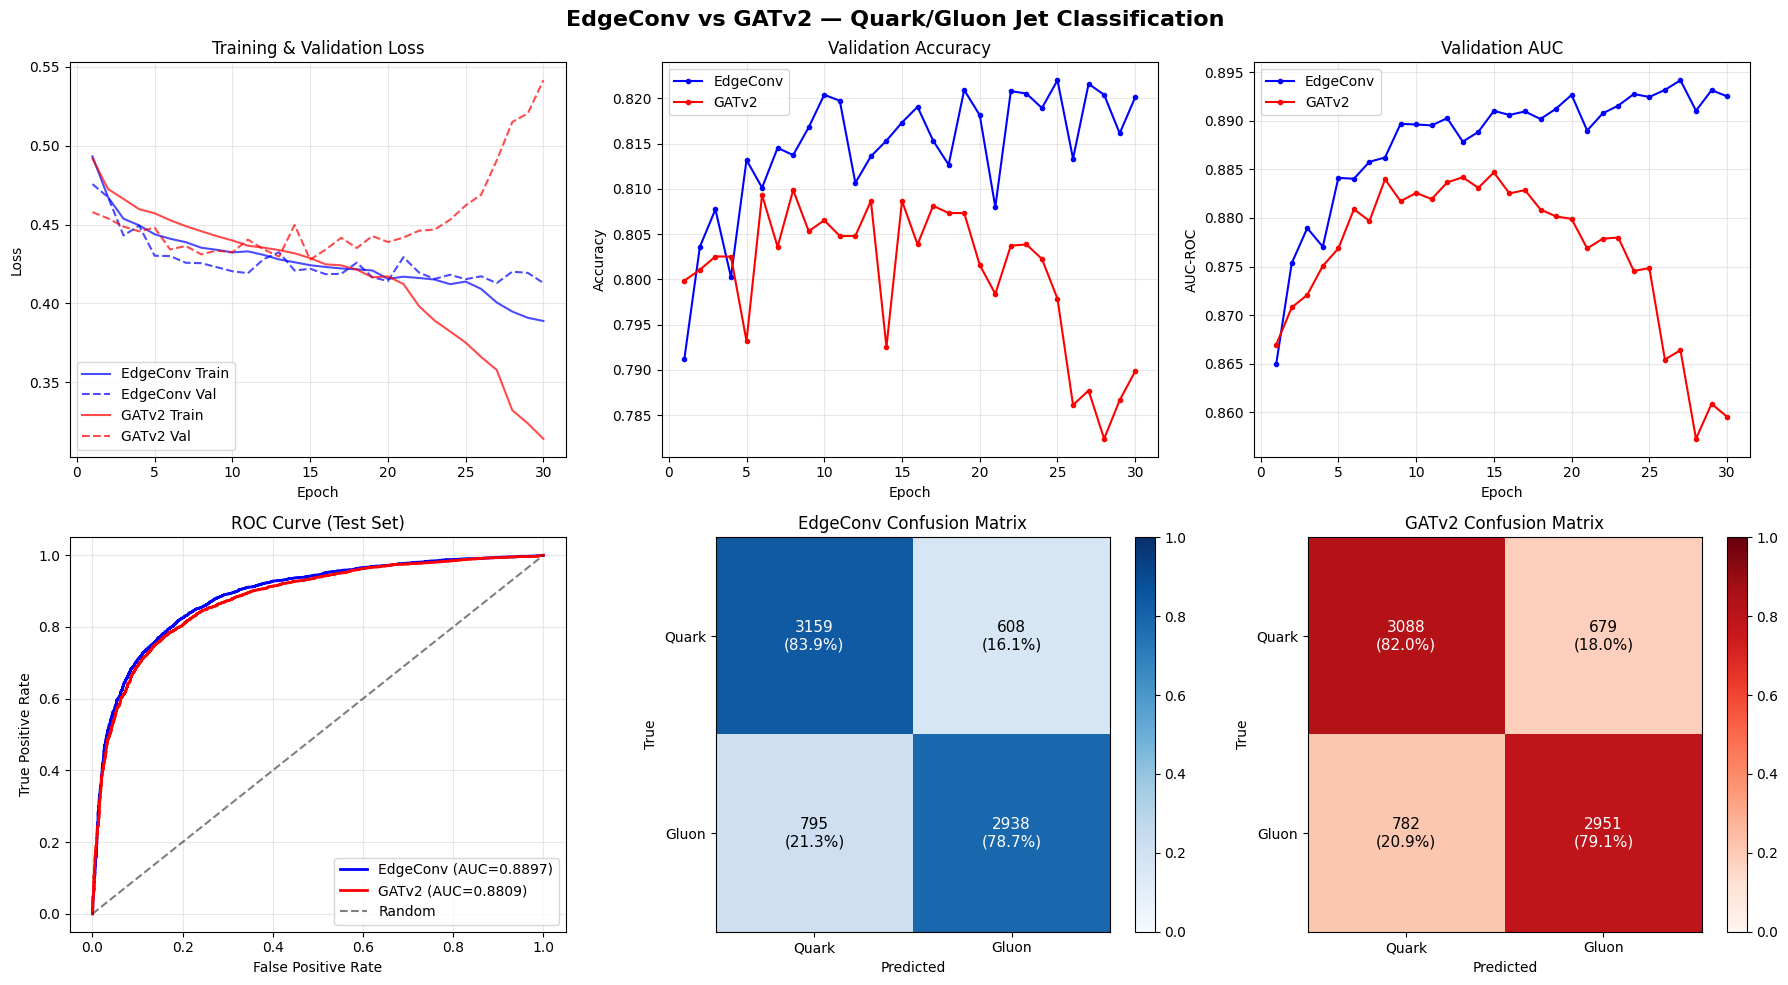

Saved -> task2_comparison.png

METRIC                      EdgeConv           GATv2          Winner
  Accuracy                    0.8129          0.8052        EdgeConv
  AUC-ROC                     0.8897          0.8809        EdgeConv
  Precision                   0.8285          0.8129        EdgeConv
  Recall                      0.7870          0.7905           GATv2
  F1-Score                    0.8073          0.8016        EdgeConv
  Parameters                 378,058         249,930


In [12]:

# =============================================================================
# Task II: Classical Graph Neural Network (GNN) — Quark/Gluon Jet Classification
# =============================================================================
#
# Dataset: ParticleNet Quark/Gluon jet dataset (QG_jets.npz)
#    
#
# Architecture 1: EdgeConv Network (DGCNN-style) — implemented from scratch
# Architecture 2: Graph Attention Network (GATv2) — implemented from scratch
#
# Dependencies: torch, numpy, scipy, scikit-learn, matplotlib
# =============================================================================


import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from scipy.spatial import cKDTree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_curve
)
import matplotlib.pyplot as plt
import time
import os

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ## 1. Data Loading and Exploration

DATA_PATH = "QG_jets.npz"
assert os.path.exists(DATA_PATH), (
    f"Dataset not found at {DATA_PATH}.\n"
    f"Download from: https://zenodo.org/record/3164691"
)

dataset = np.load(DATA_PATH)
X = dataset['X']  # Shape: (N_jets, M_particles, 4_features)
y = dataset['y']  # Shape: (N_jets,)

print(f"Total jets       : {X.shape[0]}")
print(f"Max constituents : {X.shape[1]}")
print(f"Features/particle: {X.shape[2]}")
print(f"Class distribution: Quarks(0)={int(np.sum(y==0))}, Gluons(1)={int(np.sum(y==1))}")

# Inspect one jet
sample = X[0]
real_mask = np.abs(sample).sum(axis=1) > 1e-6
print(f"\nSample jet: {real_mask.sum()} real particles out of {sample.shape[0]} padded slots")
print(f"First 5 particles:\n{sample[:5]}")

# ## 2. Graph Construction — k-NN in (eta, phi) Space

def build_knn_graph(particle_features, k=7):
    """
    Build a k-NN graph from a single jet's particle features.

    Parameters
    ----------
    particle_features : np.ndarray, shape (M, 4)
        Per-particle features. We use columns [1] and [2] as (eta, phi) for k-NN.
    k : int
        Number of nearest neighbors.

    Returns
    -------
    node_features : np.ndarray, shape (N_real, 4)
    edge_index    : np.ndarray, shape (2, num_edges), int64, bidirectional
    """
    # Remove zero-padded particles
    mask = np.abs(particle_features).sum(axis=1) > 1e-6
    real = particle_features[mask]
    n = real.shape[0]

    if n < 2:
        return real, np.zeros((2, 0), dtype=np.int64)

    # k-NN in (eta, phi) space
    coords = real[:, 1:3]
    eff_k = min(k, n - 1)
    tree = cKDTree(coords)
    _, indices = tree.query(coords, k=eff_k + 1)  # +1 because first hit is self

    # Build bidirectional edge list, deduplicated
    edge_set = set()
    src, dst = [], []
    for i in range(n):
        for j_pos in range(1, eff_k + 1):
            j = indices[i, j_pos]
            for s, d in [(i, j), (j, i)]:
                if (s, d) not in edge_set:
                    edge_set.add((s, d))
                    src.append(s)
                    dst.append(d)

    return real, np.array([src, dst], dtype=np.int64)


# Quick test
demo_feat, demo_edges = build_knn_graph(X[0], k=7)
print(f"Demo jet: {demo_feat.shape[0]} nodes, {demo_edges.shape[1]} edges, "
      f"avg degree = {demo_edges.shape[1] / demo_feat.shape[0]:.1f}")


class JetGraphDataset(Dataset):
    """Dataset of jet graphs stored as (node_features, edge_index, label)."""

    def __init__(self, X, y, k=7, verbose=True):
        super().__init__()
        self.graphs = []
        for i in range(len(X)):
            if verbose and i > 0 and i % 10000 == 0:
                print(f"  Processed {i}/{len(X)} jets...")
            nf, ei = build_knn_graph(X[i], k=k)
            if nf.shape[0] < 2:
                continue
            self.graphs.append({
                'x': torch.tensor(nf, dtype=torch.float32),
                'edge_index': torch.tensor(ei, dtype=torch.long),
                'y': torch.tensor(int(y[i]), dtype=torch.long),
            })

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]


def collate_graphs(batch):
    """
    Collate a list of graph dicts into a single batched graph.

    Returns dict with:
      x          : (total_nodes, F)   concatenated node features
      edge_index : (2, total_edges)   shifted node indices
      y          : (B,)               labels
      batch      : (total_nodes,)     graph membership per node
    """
    xs, eis, ys, batches = [], [], [], []
    offset = 0
    for i, g in enumerate(batch):
        n = g['x'].size(0)
        xs.append(g['x'])
        eis.append(g['edge_index'] + offset)
        ys.append(g['y'])
        batches.append(torch.full((n,), i, dtype=torch.long))
        offset += n

    return {
        'x': torch.cat(xs, dim=0),
        'edge_index': torch.cat(eis, dim=1),
        'y': torch.stack(ys),
        'batch': torch.cat(batches, dim=0),
    }


# Build graphs — use N_JETS for speed; set to len(X) for full dataset
N_JETS = 50000
K_NEIGHBORS = 7

print(f"Building {N_JETS} jet graphs with k={K_NEIGHBORS}...")
t0 = time.time()
full_dataset = JetGraphDataset(X[:N_JETS], y[:N_JETS], k=K_NEIGHBORS)
print(f"Built {len(full_dataset)} valid graphs in {time.time()-t0:.1f}s")

# 70 / 15 / 15 split
train_idx, temp_idx = train_test_split(
    range(len(full_dataset)), test_size=0.3, random_state=SEED
)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=SEED)

train_set = Subset(full_dataset, train_idx)
val_set   = Subset(full_dataset, val_idx)
test_set  = Subset(full_dataset, test_idx)

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_graphs)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_graphs)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_graphs)


# ## 4. Global Pooling Utilities (Pure PyTorch)

# %%
def global_mean_pool(x, batch, num_graphs):
    """Mean-pool node features per graph."""
    out = torch.zeros(num_graphs, x.size(1), device=x.device)
    count = torch.zeros(num_graphs, 1, device=x.device)
    idx = batch.unsqueeze(1).expand_as(x)
    out.scatter_add_(0, idx, x)
    count.scatter_add_(0, batch.unsqueeze(1),
                       torch.ones(x.size(0), 1, device=x.device))
    return out / count.clamp(min=1)


def global_max_pool(x, batch, num_graphs):
    """Max-pool node features per graph."""
    out = torch.full((num_graphs, x.size(1)), float('-inf'), device=x.device)
    idx = batch.unsqueeze(1).expand_as(x)
    out.scatter_reduce_(0, idx, x, reduce='amax')
    return out


# %%
class EdgeConvLayer(nn.Module):
    """
    EdgeConv: for each edge (i->j), compute MLP(x_j || x_i - x_j),
    then mean-aggregate over neighbors per node.
    Includes a residual/shortcut connection.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(2 * in_channels, out_channels),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Linear(out_channels, out_channels),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
        )
        self.shortcut = (nn.Linear(in_channels, out_channels)
                         if in_channels != out_channels else nn.Identity())

    def forward(self, x, edge_index):
        """
        x          : (N, C_in)  node features
        edge_index : (2, E)     [source, destination]
        returns    : (N, C_out)
        """
        src, dst = edge_index  # message flows src -> dst

        # Edge features: [x_dst || x_src - x_dst] (centered on receiving node)
        x_src = x[src]
        x_dst = x[dst]
        edge_feat = torch.cat([x_dst, x_src - x_dst], dim=1)  # (E, 2*C_in)
        edge_feat = self.mlp(edge_feat)                         # (E, C_out)

        # Mean aggregation onto destination nodes
        C_out = edge_feat.size(1)
        out = torch.zeros(x.size(0), C_out, device=x.device)
        count = torch.zeros(x.size(0), 1, device=x.device)
        out.scatter_add_(0, dst.unsqueeze(1).expand(-1, C_out), edge_feat)
        count.scatter_add_(0, dst.unsqueeze(1),
                           torch.ones(edge_feat.size(0), 1, device=x.device))
        out = out / count.clamp(min=1)

        return F.relu(out + self.shortcut(x))


class EdgeConvNet(nn.Module):
    """
    DGCNN-style network with stacked EdgeConv layers.
    Concatenated mean + max global pooling for graph-level readout.
    """
    def __init__(self, input_dim=4, hidden_dims=(64, 128, 256),
                 num_classes=2, dropout=0.3):
        super().__init__()
        self.input_bn = nn.BatchNorm1d(input_dim)

        self.convs = nn.ModuleList()
        dims = [input_dim] + list(hidden_dims)
        for i in range(len(hidden_dims)):
            self.convs.append(EdgeConvLayer(dims[i], dims[i + 1]))

        pool_dim = hidden_dims[-1] * 2  # mean + max
        self.classifier = nn.Sequential(
            nn.Linear(pool_dim, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, data):
        x, edge_index, batch = data['x'], data['edge_index'], data['batch']
        num_graphs = data['y'].size(0)

        x = self.input_bn(x)
        for conv in self.convs:
            x = conv(x, edge_index)

        xm = global_mean_pool(x, batch, num_graphs)
        xx = global_max_pool(x, batch, num_graphs)
        x = torch.cat([xm, xx], dim=1)
        return self.classifier(x)

class GATv2Layer(nn.Module):
    """
    Multi-head GATv2 attention layer (from scratch).

    For each head h:
        e_ij^h = (a^h)^T LeakyReLU( W^h [x_i || x_j] )
        alpha_ij^h = softmax_j(e_ij^h)
        out_i^h = sum_j alpha_ij^h * W_v^h * x_j

    Heads are concatenated -> output dim = heads * (out_channels // heads).
    """
    def __init__(self, in_channels, out_channels, heads=4, negative_slope=0.2):
        super().__init__()
        assert out_channels % heads == 0, "out_channels must be divisible by heads"
        self.heads = heads
        self.d = out_channels // heads  # per-head dimension
        self.negative_slope = negative_slope

        self.W = nn.Linear(in_channels, out_channels, bias=False)
        # Attention vector per head: scores (2*d)-dim edge features to scalar
        self.a = nn.Parameter(torch.randn(heads, 2 * self.d))
        nn.init.xavier_uniform_(self.a.unsqueeze(0))  # better init

        self.bn = nn.BatchNorm1d(out_channels)
        self.shortcut = (nn.Linear(in_channels, out_channels)
                         if in_channels != out_channels else nn.Identity())

    def forward(self, x, edge_index):
        N = x.size(0)
        src, dst = edge_index
        E = src.size(0)
        H, d = self.heads, self.d

        # Project: (N, H*d) -> (N, H, d)
        x_proj = self.W(x).view(N, H, d)

        x_src = x_proj[src]  # (E, H, d)
        x_dst = x_proj[dst]  # (E, H, d)

        # GATv2: LeakyReLU( [x_dst || x_src] ) dot a
        cat_feat = torch.cat([x_dst, x_src], dim=-1)           # (E, H, 2d)
        e = F.leaky_relu(cat_feat, self.negative_slope)         # (E, H, 2d)
        e = (e * self.a.unsqueeze(0)).sum(dim=-1)               # (E, H)

        # Numerically stable softmax grouped by destination node
        e_max = torch.full((N, H), float('-inf'), device=x.device)
        e_max.scatter_reduce_(0, dst.unsqueeze(1).expand(E, H), e, reduce='amax')
        e_stable = e - e_max[dst]
        alpha = e_stable.exp()

        alpha_sum = torch.zeros(N, H, device=x.device)
        alpha_sum.scatter_add_(0, dst.unsqueeze(1).expand(E, H), alpha)
        alpha = alpha / alpha_sum[dst].clamp(min=1e-12)         # (E, H)

        # Weighted aggregation
        weighted = alpha.unsqueeze(-1) * x_src                   # (E, H, d)
        out = torch.zeros(N, H, d, device=x.device)
        out.scatter_add_(0, dst.unsqueeze(1).unsqueeze(2).expand(E, H, d), weighted)

        out = out.reshape(N, H * d)  # concat heads
        return F.relu(self.bn(out) + self.shortcut(x))


class GATv2Net(nn.Module):
    """Graph Attention Network v2 for jet classification."""

    def __init__(self, input_dim=4, hidden_dims=(64, 128, 256),
                 heads=4, num_classes=2, dropout=0.3):
        super().__init__()
        self.input_bn = nn.BatchNorm1d(input_dim)

        self.gat_layers = nn.ModuleList()
        dims = [input_dim] + list(hidden_dims)
        for i in range(len(hidden_dims)):
            self.gat_layers.append(GATv2Layer(dims[i], dims[i + 1], heads=heads))

        pool_dim = hidden_dims[-1] * 2
        self.classifier = nn.Sequential(
            nn.Linear(pool_dim, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, data):
        x, edge_index, batch = data['x'], data['edge_index'], data['batch']
        num_graphs = data['y'].size(0)

        x = self.input_bn(x)
        for layer in self.gat_layers:
            x = layer(x, edge_index)

        xm = global_mean_pool(x, batch, num_graphs)
        xx = global_max_pool(x, batch, num_graphs)
        x = torch.cat([xm, xx], dim=1)
        return self.classifier(x)


# ## 7. Training and Evaluation

# %%
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_n = 0.0, 0
    for data in loader:
        data = {k: v.to(device) for k, v in data.items()}
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data['y'])
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data['y'].size(0)
        total_n += data['y'].size(0)
    return total_loss / total_n


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    total_loss, total_n = 0.0, 0
    criterion = nn.CrossEntropyLoss()

    for data in loader:
        data = {k: v.to(device) for k, v in data.items()}
        out = model(data)
        loss = criterion(out, data['y'])
        total_loss += loss.item() * data['y'].size(0)
        total_n += data['y'].size(0)

        probs = F.softmax(out, dim=1)
        all_preds.append(out.argmax(dim=1).cpu().numpy())
        all_probs.append(probs[:, 1].cpu().numpy())
        all_labels.append(data['y'].cpu().numpy())

    return {
        'preds':  np.concatenate(all_preds),
        'probs':  np.concatenate(all_probs),
        'labels': np.concatenate(all_labels),
        'loss':   total_loss / total_n,
    }


def compute_metrics(results, label="Model"):
    y_true, y_pred, y_prob = results['labels'], results['preds'], results['probs']

    acc  = accuracy_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    cm   = confusion_matrix(y_true, y_pred)

    print(f"\n{'='*60}")
    print(f" {label} — Test Set Metrics")
    print(f"{'='*60}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  AUC-ROC   : {auc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"               Predicted")
    print(f"              Quark  Gluon")
    print(f"  True Quark  {cm[0,0]:>5d}  {cm[0,1]:>5d}")
    print(f"  True Gluon  {cm[1,0]:>5d}  {cm[1,1]:>5d}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Quark','Gluon'])}")

    return {'acc': acc, 'auc': auc, 'prec': prec, 'rec': rec, 'f1': f1, 'cm': cm}



# ## 8. Unified Training Loop

NUM_EPOCHS   = 30
LR           = 1e-3
WEIGHT_DECAY = 1e-4
input_dim    = X.shape[2]


def train_model(model, name, num_epochs=NUM_EPOCHS):
    """Full training loop with LR scheduling, early stopping, and checkpointing."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    criterion = nn.CrossEntropyLoss()

    n_params = sum(p.numel() for p in model.parameters())
    print(f"\n{'='*60}")
    print(f" Training: {name}  ({n_params:,} parameters)")
    print(f"{'='*60}")

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
    best_auc = 0.0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_res = evaluate(model, val_loader, device)

        v_acc = accuracy_score(val_res['labels'], val_res['preds'])
        v_auc = roc_auc_score(val_res['labels'], val_res['probs'])

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_res['loss'])
        history['val_acc'].append(v_acc)
        history['val_auc'].append(v_auc)

        scheduler.step(val_res['loss'])

        if v_auc > best_auc:
            best_auc = v_auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        dt = time.time() - t0
        print(f"Epoch {epoch:>2d}/{num_epochs} | "
              f"Train Loss {tr_loss:.4f} | Val Loss {val_res['loss']:.4f} | "
              f"Val Acc {v_acc:.4f} | Val AUC {v_auc:.4f} | {dt:.1f}s")

    # Restore best weights and evaluate on test set
    model.load_state_dict(best_state)
    model = model.to(device)
    test_res = evaluate(model, test_loader, device)
    metrics  = compute_metrics(test_res, label=name)

    return model, history, test_res, metrics



# Train EdgeConv
edgeconv_model = EdgeConvNet(
    input_dim=input_dim, hidden_dims=(64, 128, 256), num_classes=2, dropout=0.3
)
edgeconv_model, ec_hist, ec_test, ec_metrics = train_model(
    edgeconv_model, "EdgeConv (DGCNN-style)"
)


# Train GATv2
gatv2_model = GATv2Net(
    input_dim=input_dim, hidden_dims=(64, 128, 256),
    heads=4, num_classes=2, dropout=0.3
)
gatv2_model, gat_hist, gat_test, gat_metrics = train_model(
    gatv2_model, "GATv2 (Graph Attention)"
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EdgeConv vs GATv2 — Quark/Gluon Jet Classification",
             fontsize=16, fontweight='bold')

epochs_range = range(1, NUM_EPOCHS + 1)

# ---- Row 0: Training curves ----
ax = axes[0, 0]
ax.plot(epochs_range, ec_hist['train_loss'],  'b-',  label='EdgeConv Train', alpha=.7)
ax.plot(epochs_range, ec_hist['val_loss'],    'b--', label='EdgeConv Val',   alpha=.7)
ax.plot(epochs_range, gat_hist['train_loss'], 'r-',  label='GATv2 Train',   alpha=.7)
ax.plot(epochs_range, gat_hist['val_loss'],   'r--', label='GATv2 Val',     alpha=.7)
ax.set(xlabel='Epoch', ylabel='Loss', title='Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=.3)

ax = axes[0, 1]
ax.plot(epochs_range, ec_hist['val_acc'],  'b-o', label='EdgeConv', ms=3)
ax.plot(epochs_range, gat_hist['val_acc'], 'r-o', label='GATv2',   ms=3)
ax.set(xlabel='Epoch', ylabel='Accuracy', title='Validation Accuracy')
ax.legend()
ax.grid(True, alpha=.3)

ax = axes[0, 2]
ax.plot(epochs_range, ec_hist['val_auc'],  'b-o', label='EdgeConv', ms=3)
ax.plot(epochs_range, gat_hist['val_auc'], 'r-o', label='GATv2',   ms=3)
ax.set(xlabel='Epoch', ylabel='AUC-ROC', title='Validation AUC')
ax.legend()
ax.grid(True, alpha=.3)

# ---- Row 1: Test-set evaluation ----
ax = axes[1, 0]
fpr_ec, tpr_ec, _ = roc_curve(ec_test['labels'], ec_test['probs'])
fpr_gat, tpr_gat, _ = roc_curve(gat_test['labels'], gat_test['probs'])
ax.plot(fpr_ec,  tpr_ec,  'b-', lw=2,
        label=f'EdgeConv (AUC={ec_metrics["auc"]:.4f})')
ax.plot(fpr_gat, tpr_gat, 'r-', lw=2,
        label=f'GATv2 (AUC={gat_metrics["auc"]:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=.5, label='Random')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='ROC Curve (Test Set)')
ax.legend(loc='lower right')
ax.grid(True, alpha=.3)

# Confusion matrices
for idx, (met, name, cmap) in enumerate([
    (ec_metrics,  'EdgeConv', 'Blues'),
    (gat_metrics, 'GATv2',    'Reds'),
]):
    ax = axes[1, idx + 1]
    cm = met['cm']
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_n, cmap=cmap, vmin=0, vmax=1)
    ax.set(xticks=[0, 1], yticks=[0, 1],
           title=f'{name} Confusion Matrix',
           xlabel='Predicted', ylabel='True')
    ax.set_xticklabels(['Quark', 'Gluon'])
    ax.set_yticklabels(['Quark', 'Gluon'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]}\n({cm_n[i,j]:.1%})',
                    ha='center', va='center',
                    color='white' if cm_n[i, j] > .5 else 'black',
                    fontsize=11)
    plt.colorbar(im, ax=ax, fraction=.046)

plt.tight_layout()
plt.savefig("task2_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> task2_comparison.png")

# ## 10. Summary Comparison Table

print("\n" + "=" * 70)
print(f"{'METRIC':<20} {'EdgeConv':>15} {'GATv2':>15} {'Winner':>15}")
print("=" * 70)
for name, key in [('Accuracy', 'acc'), ('AUC-ROC', 'auc'),
                   ('Precision', 'prec'), ('Recall', 'rec'), ('F1-Score', 'f1')]:
    e, g = ec_metrics[key], gat_metrics[key]
    w = "EdgeConv" if e > g else ("GATv2" if g > e else "Tie")
    print(f"  {name:<18} {e:>15.4f} {g:>15.4f} {w:>15}")

ec_p = sum(p.numel() for p in edgeconv_model.parameters())
gat_p = sum(p.numel() for p in gatv2_model.parameters())
print(f"  {'Parameters':<18} {ec_p:>15,} {gat_p:>15,}")
print("=" * 70)


# Task III

In [13]:
# Link: https://drive.google.com/file/d/16yabjJ33dzomGjiM-3YhiZHJeb5k3nUc/view?usp=sharing

# Task V 

# Task VI

In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import warnings
import time

warnings.filterwarnings('ignore')
np.random.seed(42)
print(f"PennyLane version: {qml.__version__}")

PennyLane version: 0.38.0


Loading MNIST...
Full dataset: 70000 images, 784 pixels
Subset: 800 images, 80 per class
PCA variance explained: 0.458
Final features: shape (800, 8), range [0.000, 3.142]


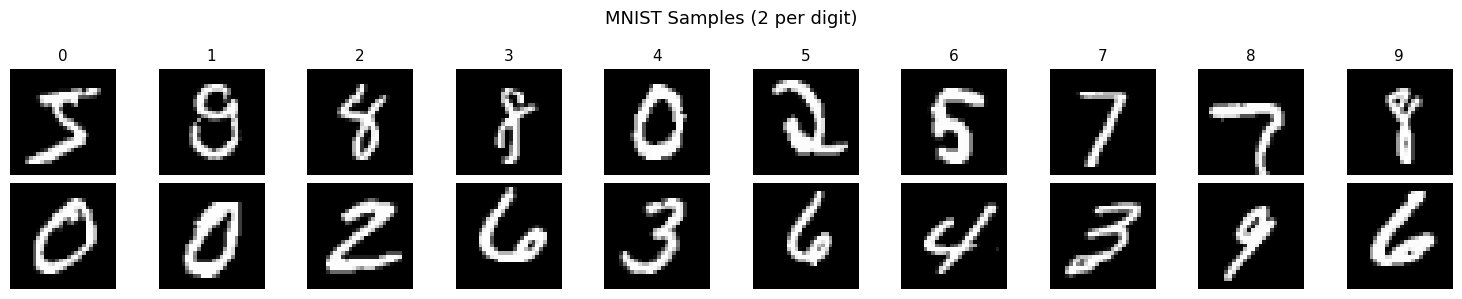

In [2]:
# ## 1. Load and Preprocess MNIST

print("Loading MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_full, y_full = mnist.data, mnist.target.astype(int)
print(f"Full dataset: {X_full.shape[0]} images, {X_full.shape[1]} pixels")


# Use a subset for tractable quantum simulation
# Take N_PER_CLASS images per digit (0-9)
N_PER_CLASS = 80
N_CLASSES = 10

X_sub, y_sub = [], []
for digit in range(N_CLASSES):
    mask = y_full == digit
    idx = np.where(mask)[0][:N_PER_CLASS]
    X_sub.append(X_full[idx])
    y_sub.append(y_full[idx])

X_sub = np.array(np.vstack(X_sub), requires_grad=False)
y_sub = np.array(np.concatenate(y_sub), requires_grad=False)

print(f"Subset: {X_sub.shape[0]} images, {N_PER_CLASS} per class")


# Dimensionality reduction: 784 → 8 features via PCA
N_FEATURES = 8
N_QUBITS = 4  # Qubits per register (2 features encoded per qubit)

pca = PCA(n_components=N_FEATURES)
X_pca = pca.fit_transform(X_sub)
print(f"PCA variance explained: {pca.explained_variance_ratio_.sum():.3f}")

# Scale features to [0, π] for rotation gates
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = np.array(scaler.fit_transform(X_pca), requires_grad=False)

print(f"Final features: shape {X_scaled.shape}, range [{X_scaled.min():.3f}, {X_scaled.max():.3f}]")


# Visualize some samples
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle("MNIST Samples (2 per digit)", fontsize=13)
for digit in range(10):
    mask = y_sub == digit
    idx = np.where(mask)[0]
    for row in range(2):
        ax = axes[row, digit]
        ax.imshow(X_full[idx[row] if row < len(idx) else idx[0]].reshape(28, 28),
                  cmap='gray')
        ax.axis('off')
        if row == 0:
            ax.set_title(str(digit), fontsize=11)
plt.tight_layout()
plt.savefig("task6_mnist_samples.png", dpi=150, bbox_inches='tight')
plt.show()



In [3]:

N_EMBED_LAYERS = 3  # Number of variational layers in the embedding

def quantum_embedding(features, params, wires):
    """
    Trainable quantum state preparation for a single image.

    Parameters
    ----------
    features : array, shape (8,)
        PCA-reduced, scaled image features.
    params : array, shape (N_EMBED_LAYERS, N_QUBITS, 2)
        Trainable rotation parameters [θ_RY, θ_RZ] per qubit per layer.
    wires : list of int
        Which qubits this embedding acts on.
    """
    n_qubits = len(wires)

    for layer in range(N_EMBED_LAYERS):
        # --- Data encoding: 2 features per qubit ---
        for i, w in enumerate(wires):
            qml.RY(features[2 * i], wires=w)
            qml.RZ(features[2 * i + 1], wires=w)

        # --- Trainable rotations ---
        for i, w in enumerate(wires):
            qml.RY(params[layer, i, 0], wires=w)
            qml.RZ(params[layer, i, 1], wires=w)

        # --- Entangling layer: CNOT ring ---
        for i in range(n_qubits):
            qml.CNOT(wires=[wires[i], wires[(i + 1) % n_qubits]])




Register A: qubits [0, 1, 2, 3]
Register B: qubits [4, 5, 6, 7]
Ancilla:    qubit  8
Total:      9 qubits
 SWAP Test Circuit for Quantum Contrastive Learning
 Qubits per register : 4
 Embedding layers    : 3
 Trainable params    : 24
 Total qubits        : 9

0: ──RY(0.26)──RZ(0.94)──RY(1.45)───RZ(0.49)──╭●───────╭X──RY(0.26)──RZ(0.94)──RY(-0.12)──RZ(0.97)
1: ──RY(1.62)──RZ(1.28)──RY(-1.65)──RZ(-1.49)─╰X─╭●────│───RY(1.62)──RZ(1.28)──RY(-1.95)──RZ(0.21)
2: ──RY(0.14)──RZ(3.01)──RY(-0.06)──RZ(-0.51)────╰X─╭●─│───RY(0.14)──RZ(3.01)──RY(-1.14)──RZ(0.17)
3: ──RY(2.99)──RZ(0.88)──RY(-1.31)──RZ(1.93)────────╰X─╰●──RY(2.99)──RZ(0.88)──RY(1.76)───RZ(1.69)
4: ──RY(0.26)──RZ(0.94)──RY(1.45)───RZ(0.49)──╭●───────╭X──RY(0.26)──RZ(0.94)──RY(-0.12)──RZ(0.97)
5: ──RY(1.62)──RZ(1.28)──RY(-1.65)──RZ(-1.49)─╰X─╭●────│───RY(1.62)──RZ(1.28)──RY(-1.95)──RZ(0.21)
6: ──RY(0.14)──RZ(3.01)──RY(-0.06)──RZ(-0.51)────╰X─╭●─│───RY(0.14)──RZ(3.01)──RY(-1.14)──RZ(0.17)
7: ──RY(2.99)──RZ(0.88)──RY(-1.31)──RZ(1.93)───

Matplotlib is building the font cache; this may take a moment.


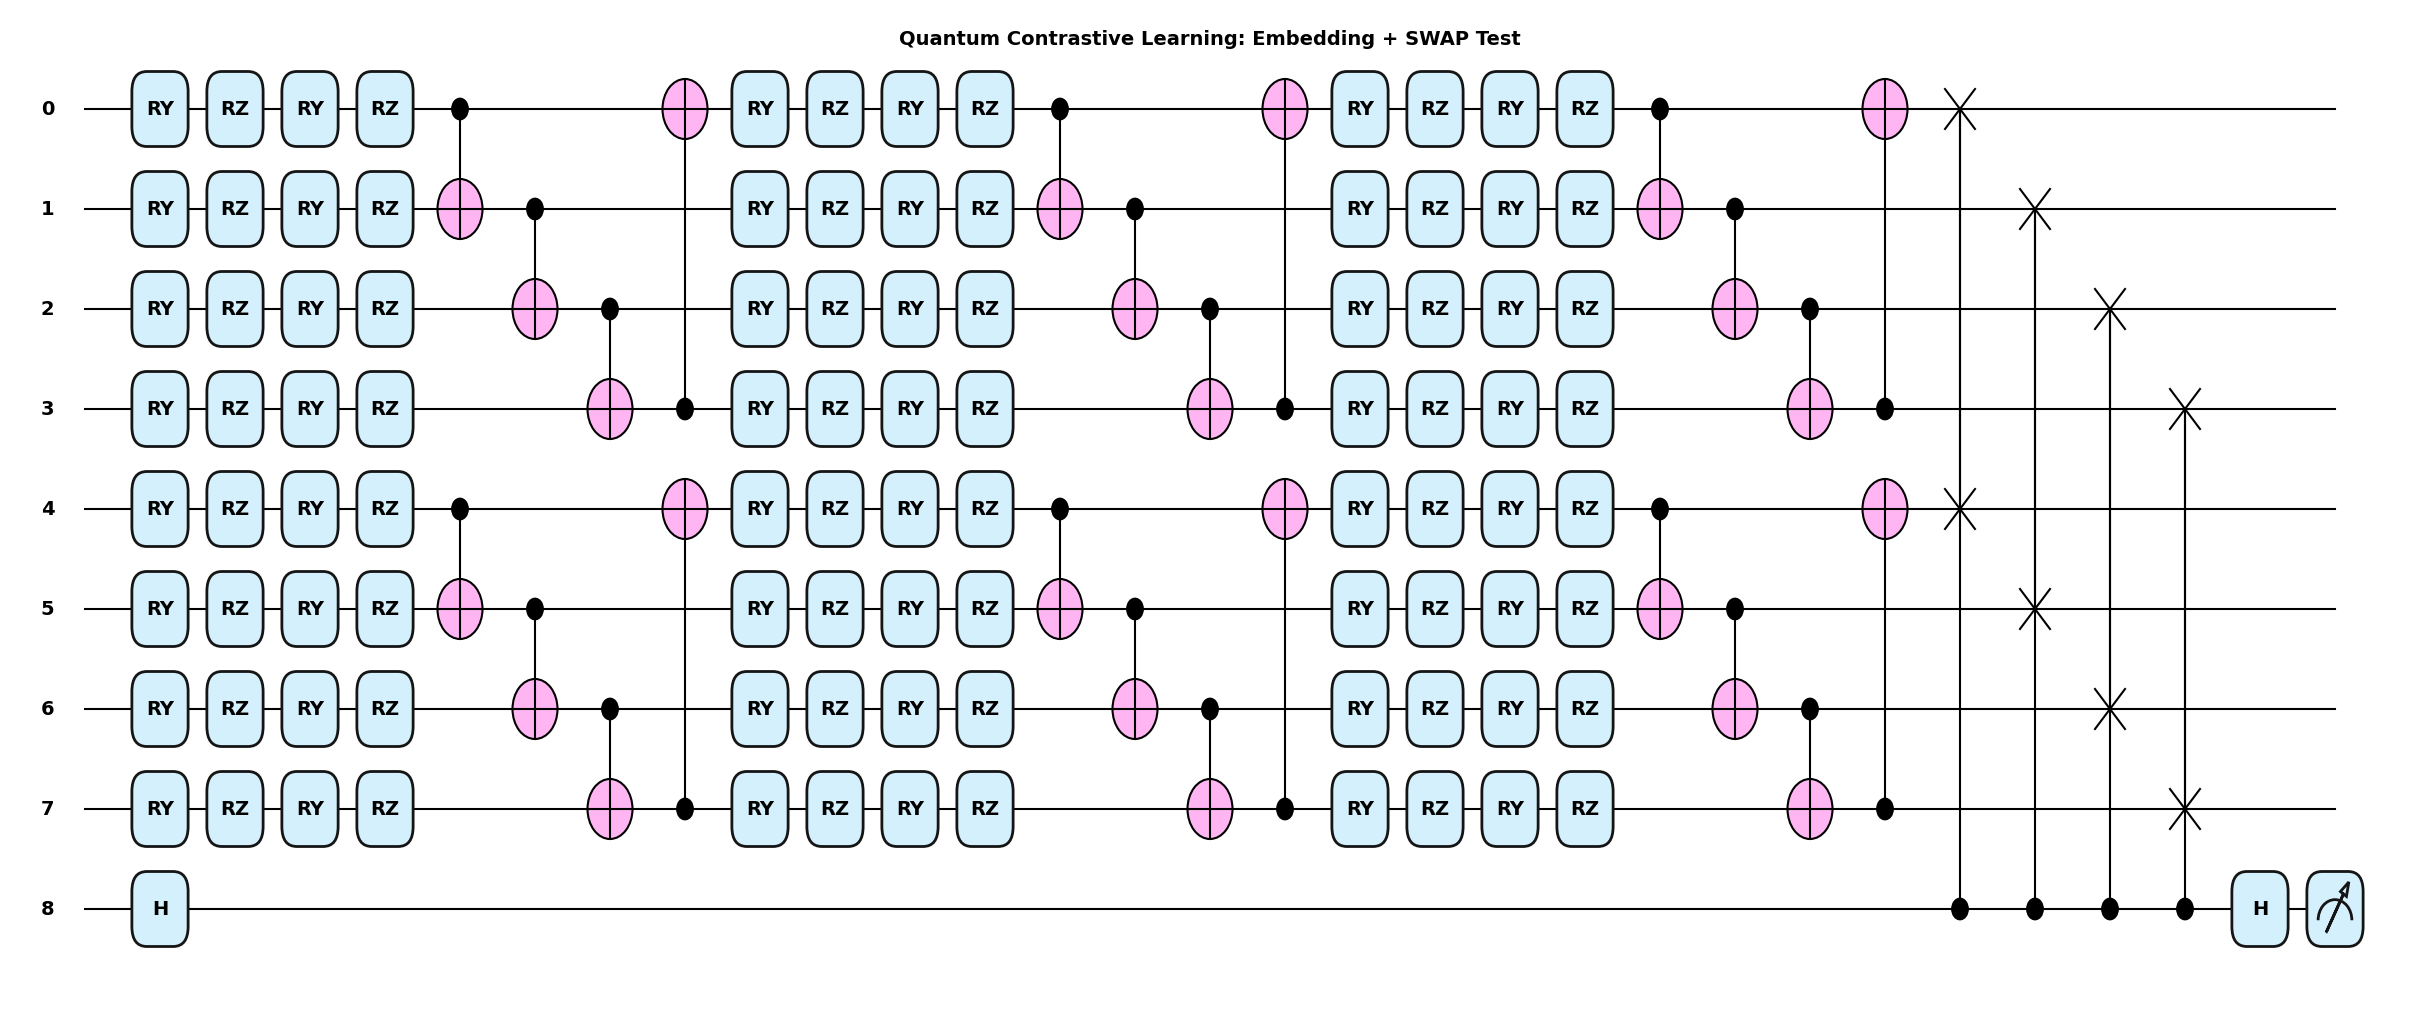

Saved → task6_circuit.png


In [4]:

# Define qubit registers
reg_a = list(range(N_QUBITS))                          # [0, 1, 2, 3]
reg_b = list(range(N_QUBITS, 2 * N_QUBITS))            # [4, 5, 6, 7]
ancilla = 2 * N_QUBITS                                  # 8
total_qubits = 2 * N_QUBITS + 1                         # 9

print(f"Register A: qubits {reg_a}")
print(f"Register B: qubits {reg_b}")
print(f"Ancilla:    qubit  {ancilla}")
print(f"Total:      {total_qubits} qubits")

# %%
dev = qml.device("default.qubit", wires=total_qubits)

@qml.qnode(dev, interface="autograd")
def swap_test_circuit(features_a, features_b, params):
    """
    Full circuit: embed two images → SWAP test → fidelity.

    Parameters
    ----------
    features_a : array (8,) — first image features
    features_b : array (8,) — second image features
    params     : array (N_EMBED_LAYERS, N_QUBITS, 2) — shared embedding params

    Returns
    -------
    ⟨Z_ancilla⟩ = |⟨ψ_a|ψ_b⟩|² (fidelity between quantum representations)
    """
    # --- Embed image A into register A ---
    quantum_embedding(features_a, params, wires=reg_a)

    # --- Embed image B into register B ---
    # Same params (weight sharing: both images use the same learned embedding)
    quantum_embedding(features_b, params, wires=reg_b)

    # --- SWAP Test ---
    qml.Hadamard(wires=ancilla)

    for i in range(N_QUBITS):
        qml.CSWAP(wires=[ancilla, reg_a[i], reg_b[i]])

    qml.Hadamard(wires=ancilla)

    # ⟨Z⟩ on ancilla = |⟨ψ_a|ψ_b⟩|²
    return qml.expval(qml.PauliZ(ancilla))



# ## 4. Draw the Circuit


# Sample inputs for visualization
sample_feat = np.random.uniform(0, np.pi, N_FEATURES)
sample_params = np.random.uniform(-np.pi, np.pi, (N_EMBED_LAYERS, N_QUBITS, 2))

print("=" * 70)
print(" SWAP Test Circuit for Quantum Contrastive Learning")
print("=" * 70)
print(f" Qubits per register : {N_QUBITS}")
print(f" Embedding layers    : {N_EMBED_LAYERS}")
print(f" Trainable params    : {sample_params.size}")
print(f" Total qubits        : {total_qubits}")
print("=" * 70)

# Text circuit diagram
print("\n" + qml.draw(swap_test_circuit)(sample_feat, sample_feat, sample_params))

# %%
# Matplotlib circuit diagram
fig, ax = qml.draw_mpl(swap_test_circuit, style="pennylane")(
    sample_feat, sample_feat, sample_params
)
fig.set_size_inches(24, 10)
fig.suptitle("Quantum Contrastive Learning: Embedding + SWAP Test",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("task6_circuit.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → task6_circuit.png")


Trainable parameters: 24
  Shape: (3, 4, 2) = 3 layers × 4 qubits × 2 rotations

 Training Quantum Contrastive Embedding
 4 qubits/register | 3 layers | 60 pairs/epoch | 25 epochs
Epoch   1/25 | Loss: 0.3874 | Pos Fid: 0.289 | Neg Fid: 0.122 | 2.0s
Epoch   2/25 | Loss: 0.4493 | Pos Fid: 0.221 | Neg Fid: 0.183 | 2.0s
Epoch   4/25 | Loss: 0.4043 | Pos Fid: 0.240 | Neg Fid: 0.100 | 2.0s
Epoch   6/25 | Loss: 0.4051 | Pos Fid: 0.269 | Neg Fid: 0.132 | 1.9s
Epoch   8/25 | Loss: 0.3723 | Pos Fid: 0.330 | Neg Fid: 0.133 | 2.0s
Epoch  10/25 | Loss: 0.3404 | Pos Fid: 0.412 | Neg Fid: 0.154 | 2.0s
Epoch  12/25 | Loss: 0.3483 | Pos Fid: 0.361 | Neg Fid: 0.107 | 2.1s
Epoch  14/25 | Loss: 0.3474 | Pos Fid: 0.351 | Neg Fid: 0.096 | 1.9s
Epoch  16/25 | Loss: 0.3915 | Pos Fid: 0.301 | Neg Fid: 0.142 | 2.0s
Epoch  18/25 | Loss: 0.4332 | Pos Fid: 0.191 | Neg Fid: 0.114 | 2.0s
Epoch  20/25 | Loss: 0.3903 | Pos Fid: 0.283 | Neg Fid: 0.122 | 2.0s
Epoch  22/25 | Loss: 0.4158 | Pos Fid: 0.238 | Neg Fid: 0.123

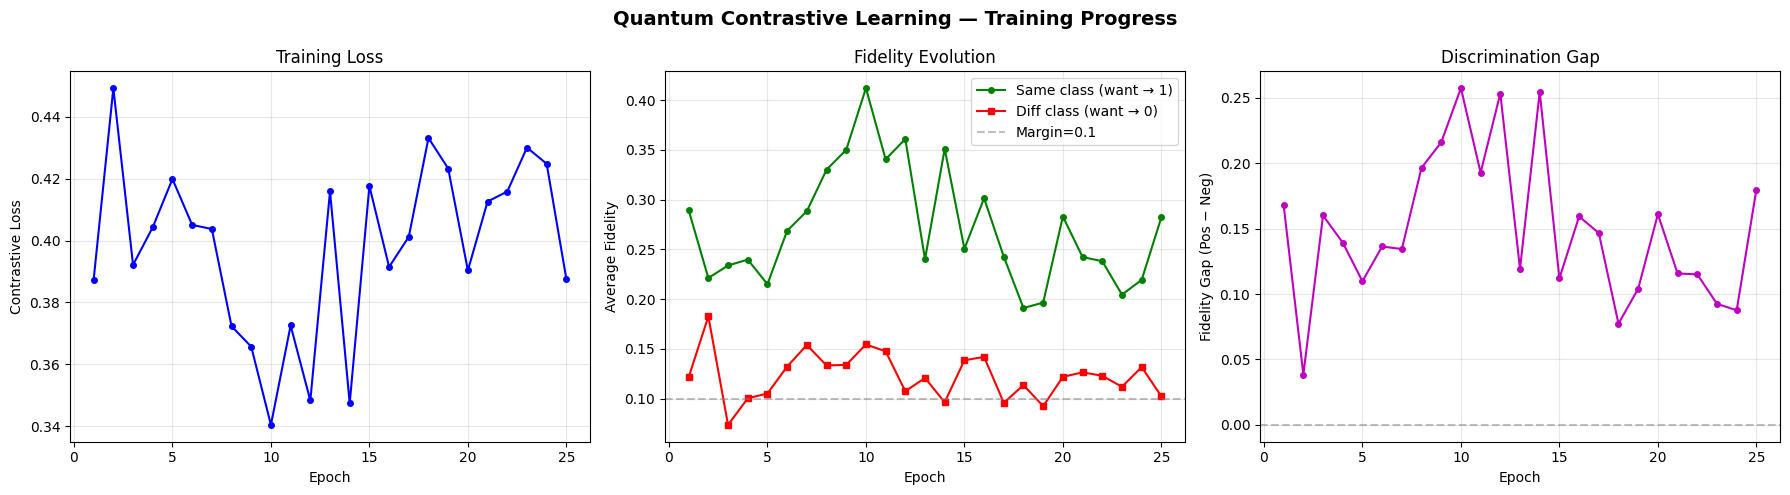

In [5]:

MARGIN = 0.1  # Fidelity margin for negative pairs


def contrastive_loss(fidelity, same_class):
    """
    Contrastive loss for a single pair.

    Parameters
    ----------
    fidelity   : float, |⟨ψ_a|ψ_b⟩|² ∈ [0, 1]
    same_class : int, 1 if same class, 0 if different

    Returns
    -------
    loss : float
    """
    if same_class:
        return 1.0 - fidelity  # Maximize fidelity
    else:
        return np.maximum(0.0, fidelity - MARGIN)  # Push below margin



def sample_pairs(X, y, n_pairs):
    """
    Sample balanced positive + negative pairs.

    Returns
    -------
    pairs : list of (idx_a, idx_b, same_class)
    """
    classes = np.unique(y)
    pairs = []

    # Positive pairs (same class)
    for _ in range(n_pairs // 2):
        cls = np.random.choice(classes)
        idx_cls = np.where(y == cls)[0]
        a, b = np.random.choice(idx_cls, size=2, replace=False)
        pairs.append((int(a), int(b), 1))

    # Negative pairs (different classes)
    for _ in range(n_pairs - n_pairs // 2):
        cls1, cls2 = np.random.choice(classes, size=2, replace=False)
        a = np.random.choice(np.where(y == cls1)[0])
        b = np.random.choice(np.where(y == cls2)[0])
        pairs.append((int(a), int(b), 0))

    np.random.shuffle(pairs)
    return pairs


# %% [markdown]
# ## 7. Training

# %%
# Initialize trainable parameters
params = np.random.uniform(-np.pi, np.pi,
                            (N_EMBED_LAYERS, N_QUBITS, 2), requires_grad=True)

print(f"Trainable parameters: {params.size}")
print(f"  Shape: {params.shape} = {N_EMBED_LAYERS} layers × {N_QUBITS} qubits × 2 rotations")

# %%
# Training configuration
NUM_EPOCHS = 25
PAIRS_PER_EPOCH = 60   # Number of pairs per epoch
LR = 0.08

optimizer = qml.AdamOptimizer(stepsize=LR)

# Training history
history = {
    'loss': [], 'pos_fidelity': [], 'neg_fidelity': []
}

print(f"\n{'='*65}")
print(f" Training Quantum Contrastive Embedding")
print(f" {N_QUBITS} qubits/register | {N_EMBED_LAYERS} layers | "
      f"{PAIRS_PER_EPOCH} pairs/epoch | {NUM_EPOCHS} epochs")
print(f"{'='*65}")

t_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # Sample pairs for this epoch
    pairs = sample_pairs(X_scaled, y_sub, PAIRS_PER_EPOCH)

    epoch_loss = 0.0
    pos_fids, neg_fids = [], []

    for idx_a, idx_b, same_class in pairs:
        feat_a = X_scaled[idx_a]
        feat_b = X_scaled[idx_b]

        # Define cost for this pair
        def cost_fn(p):
            fidelity = swap_test_circuit(feat_a, feat_b, p)
            return contrastive_loss(fidelity, same_class)

        params, loss_val = optimizer.step_and_cost(cost_fn, params)
        epoch_loss += float(loss_val)

        # Track fidelities (forward pass only, no grad)
        fid = float(swap_test_circuit(feat_a, feat_b, params))
        if same_class:
            pos_fids.append(fid)
        else:
            neg_fids.append(fid)

    avg_loss = epoch_loss / len(pairs)
    avg_pos = np.mean(pos_fids) if pos_fids else 0
    avg_neg = np.mean(neg_fids) if neg_fids else 0

    history['loss'].append(avg_loss)
    history['pos_fidelity'].append(avg_pos)
    history['neg_fidelity'].append(avg_neg)

    dt = time.time() - t0
    if epoch % 2 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | "
              f"Pos Fid: {avg_pos:.3f} | Neg Fid: {avg_neg:.3f} | {dt:.1f}s")

total_time = time.time() - t_start
print(f"\nTotal training time: {total_time:.0f}s")




# %%
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
ax = axes[0]
ax.plot(range(1, NUM_EPOCHS+1), history['loss'], 'b-o', ms=4)
ax.set(xlabel='Epoch', ylabel='Contrastive Loss', title='Training Loss')
ax.grid(True, alpha=0.3)

# Fidelity curves
ax = axes[1]
ax.plot(range(1, NUM_EPOCHS+1), history['pos_fidelity'],
        'g-o', ms=4, label='Same class (want → 1)')
ax.plot(range(1, NUM_EPOCHS+1), history['neg_fidelity'],
        'r-s', ms=4, label='Diff class (want → 0)')
ax.axhline(y=MARGIN, color='gray', linestyle='--', alpha=0.5, label=f'Margin={MARGIN}')
ax.set(xlabel='Epoch', ylabel='Average Fidelity', title='Fidelity Evolution')
ax.legend()
ax.grid(True, alpha=0.3)

# Fidelity gap
ax = axes[2]
gaps = [p - n for p, n in zip(history['pos_fidelity'], history['neg_fidelity'])]
ax.plot(range(1, NUM_EPOCHS+1), gaps, 'm-o', ms=4)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set(xlabel='Epoch', ylabel='Fidelity Gap (Pos − Neg)',
       title='Discrimination Gap')
ax.grid(True, alpha=0.3)

plt.suptitle("Quantum Contrastive Learning — Training Progress",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("task6_training.png", dpi=150, bbox_inches='tight')
plt.show()


Evaluating 20 images (2 per digit)
Computing pairwise fidelities...


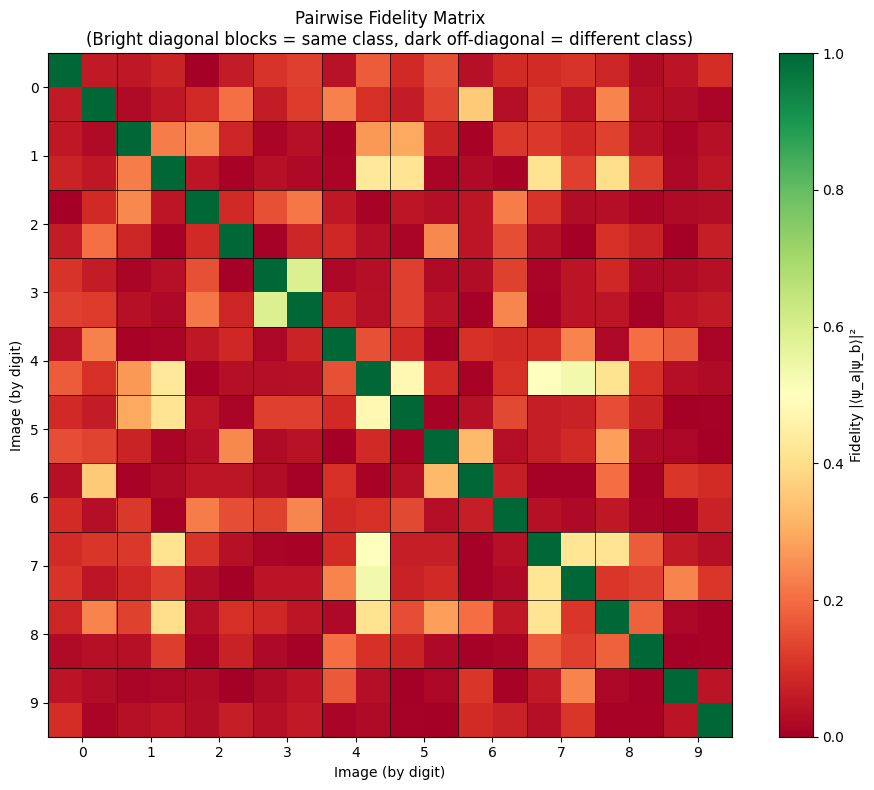

 Evaluation Metrics
  Intra-class fidelity (same digit):
    Mean: 0.1834 ± 0.1755
    Min:  0.0102,  Max: 0.5867
  Inter-class fidelity (different digits):
    Mean: 0.0945 ± 0.1074
    Min:  0.0010,  Max: 0.5347
  Separation gap: 0.0889


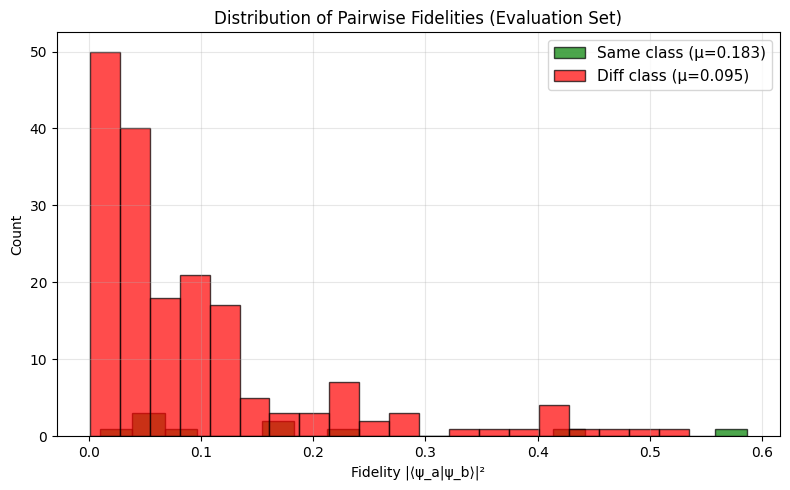

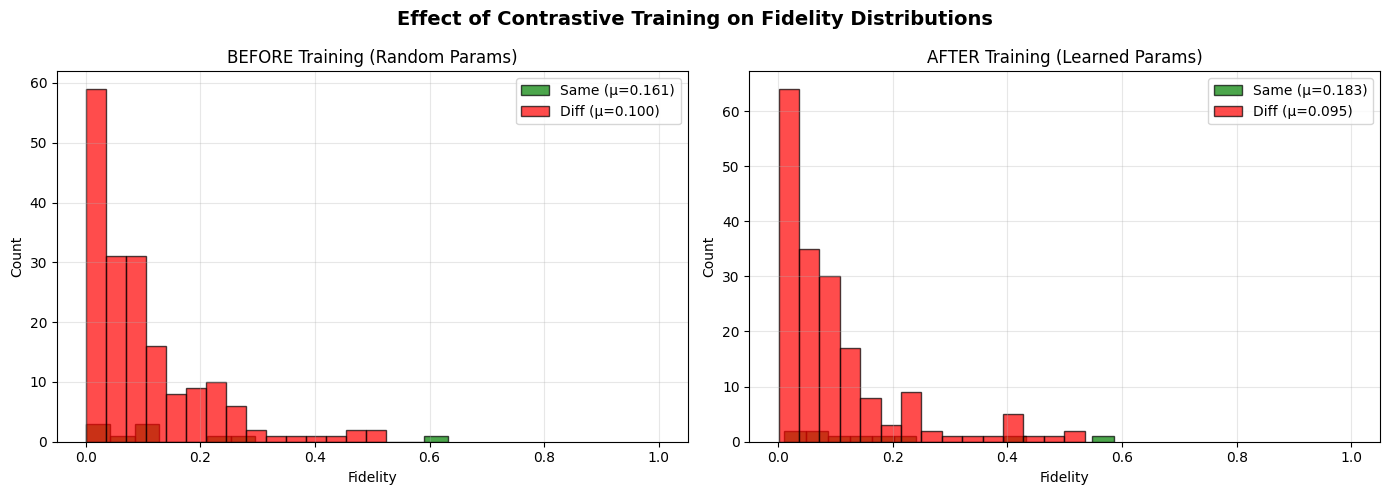


Separation gap (intra - inter fidelity):
  Before training: 0.0608
  After training:  0.0889
  Improvement:     0.0281


In [6]:

#Evaluation: Fidelity Matrix

N_EVAL = 2
eval_indices = []
eval_labels = []
for digit in range(N_CLASSES):
    idx = np.where(y_sub == digit)[0][N_PER_CLASS - N_EVAL : N_PER_CLASS]
    eval_indices.extend(idx.tolist())
    eval_labels.extend([digit] * N_EVAL)

eval_labels = np.array(eval_labels)
n_eval = len(eval_indices)
print(f"Evaluating {n_eval} images ({N_EVAL} per digit)")

# Compute fidelity matrix
fidelity_matrix = np.zeros((n_eval, n_eval), requires_grad=False)
print("Computing pairwise fidelities...")
for i in range(n_eval):
    for j in range(i, n_eval):
        fid = float(swap_test_circuit(
            X_scaled[eval_indices[i]],
            X_scaled[eval_indices[j]],
            params
        ))
        fidelity_matrix[i, j] = fid
        fidelity_matrix[j, i] = fid


# Plot fidelity matrix
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
im = ax.imshow(fidelity_matrix, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Fidelity |⟨ψ_a|ψ_b⟩|²')

# Add digit labels
tick_pos = [N_EVAL * d + N_EVAL / 2 - 0.5 for d in range(N_CLASSES)]
ax.set_xticks(tick_pos)
ax.set_yticks(tick_pos)
ax.set_xticklabels([str(d) for d in range(N_CLASSES)])
ax.set_yticklabels([str(d) for d in range(N_CLASSES)])

# Add grid lines to separate digit blocks
for d in range(1, N_CLASSES):
    ax.axhline(y=d * N_EVAL - 0.5, color='black', linewidth=0.5)
    ax.axvline(x=d * N_EVAL - 0.5, color='black', linewidth=0.5)

ax.set(xlabel='Image (by digit)', ylabel='Image (by digit)',
       title='Pairwise Fidelity Matrix\n(Bright diagonal blocks = same class, dark off-diagonal = different class)')
plt.tight_layout()
plt.savefig("task6_fidelity_matrix.png", dpi=150, bbox_inches='tight')
plt.show()



# Quantitative Evaluation


intra_fids, inter_fids = [], []
for i in range(n_eval):
    for j in range(i + 1, n_eval):
        if eval_labels[i] == eval_labels[j]:
            intra_fids.append(fidelity_matrix[i, j])
        else:
            inter_fids.append(fidelity_matrix[i, j])

intra_fids = np.array(intra_fids)
inter_fids = np.array(inter_fids)

print("=" * 55)
print(" Evaluation Metrics")
print("=" * 55)
print(f"  Intra-class fidelity (same digit):")
print(f"    Mean: {np.mean(intra_fids):.4f} ± {np.std(intra_fids):.4f}")
print(f"    Min:  {np.min(intra_fids):.4f},  Max: {np.max(intra_fids):.4f}")
print(f"  Inter-class fidelity (different digits):")
print(f"    Mean: {np.mean(inter_fids):.4f} ± {np.std(inter_fids):.4f}")
print(f"    Min:  {np.min(inter_fids):.4f},  Max: {np.max(inter_fids):.4f}")
print(f"  Separation gap: {np.mean(intra_fids) - np.mean(inter_fids):.4f}")
print("=" * 55)


# Histogram of fidelities
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.hist(intra_fids, bins=20, alpha=0.7, label=f'Same class (μ={np.mean(intra_fids):.3f})',
        color='green', edgecolor='black')
ax.hist(inter_fids, bins=20, alpha=0.7, label=f'Diff class (μ={np.mean(inter_fids):.3f})',
        color='red', edgecolor='black')
ax.set(xlabel='Fidelity |⟨ψ_a|ψ_b⟩|²', ylabel='Count',
       title='Distribution of Pairwise Fidelities (Evaluation Set)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("task6_fidelity_histogram.png", dpi=150, bbox_inches='tight')
plt.show()



# Random untrained parameters
random_params = np.random.uniform(-np.pi, np.pi,
                                   (N_EMBED_LAYERS, N_QUBITS, 2),
                                   requires_grad=False)

# Compute fidelities with random params
rand_intra, rand_inter = [], []
for i in range(n_eval):
    for j in range(i + 1, n_eval):
        fid = float(swap_test_circuit(
            X_scaled[eval_indices[i]],
            X_scaled[eval_indices[j]],
            random_params
        ))
        if eval_labels[i] == eval_labels[j]:
            rand_intra.append(fid)
        else:
            rand_inter.append(fid)

rand_intra = np.array(rand_intra)
rand_inter = np.array(rand_inter)

# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(rand_intra, bins=15, alpha=0.7, label=f'Same (μ={np.mean(rand_intra):.3f})',
        color='green', edgecolor='black')
ax.hist(rand_inter, bins=15, alpha=0.7, label=f'Diff (μ={np.mean(rand_inter):.3f})',
        color='red', edgecolor='black')
ax.set(xlabel='Fidelity', ylabel='Count', title='BEFORE Training (Random Params)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.05, 1.05)

ax = axes[1]
ax.hist(intra_fids, bins=15, alpha=0.7, label=f'Same (μ={np.mean(intra_fids):.3f})',
        color='green', edgecolor='black')
ax.hist(inter_fids, bins=15, alpha=0.7, label=f'Diff (μ={np.mean(inter_fids):.3f})',
        color='red', edgecolor='black')
ax.set(xlabel='Fidelity', ylabel='Count', title='AFTER Training (Learned Params)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.05, 1.05)

plt.suptitle("Effect of Contrastive Training on Fidelity Distributions",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("task6_before_after.png", dpi=150, bbox_inches='tight')
plt.show()

rand_gap = np.mean(rand_intra) - np.mean(rand_inter)
trained_gap = np.mean(intra_fids) - np.mean(inter_fids)
print(f"\nSeparation gap (intra - inter fidelity):")
print(f"  Before training: {rand_gap:.4f}")
print(f"  After training:  {trained_gap:.4f}")
print(f"  Improvement:     {trained_gap - rand_gap:.4f}")
